Matching Algorithm Tests
========================

Bahrudin uses ratio, energy measured by the tiles, std on x, y, z directions, 5 variables, 
and trains a neutral network

In [1]:
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import matplotlib.colors as colors

In [2]:
edepsim_path = '/Users/yuntse/data/lartpc_rd/gampix/g4/radiologicals/fullgeoanatruth-vd-reduced_g4_00.h5'
sim_output_path = '/Users/yuntse/data/lartpc_rd/gampix/detsim/radiologicals/gampixpy_fullgeoanatruth-vd-reduced_g4_00_2Mhz_segmentlabel_lowtrig_5mmpitch.h5'

In [3]:
# GAMPixPy outputs
with h5py.File(sim_output_path, 'r') as simf:
    # Print all top-level groups/datasets
    print(list(simf.keys()))
    fT = simf['tiles']
    fP = simf['pixels']
    fM = simf['meta']
    print(fT.dtype)
    print(fP.dtype)
    print(fM.dtype)

    tempT = fT[()]
    tempP = fP[()]
    tempM = fM[()]

['meta', 'pixels', 'tiles']
[('event id', '<u4'), ('tile tpc', '<u4'), ('tile x', '<f4'), ('tile y', '<f4'), ('trig z', '<f4'), ('trig t', '<f4'), ('waveform', '<f4', (20,)), ('attribution', '<f4', (20, 3)), ('label', '<i4', (3,))]
[('event id', '<u4'), ('pixel tpc', '<u4'), ('pixel x', '<f4'), ('pixel y', '<f4'), ('trig z', '<f4'), ('trig t', '<f4'), ('waveform', '<f4', (20,)), ('attribution', '<f4', (20, 3)), ('label', '<i4', (3,))]
[('event id', '<u4'), ('primary energy', '<f4'), ('deposited charge', '<f4'), ('vertex x', '<f4'), ('vertex y', '<f4'), ('vertex z', '<f4'), ('theta', '<f4'), ('phi', '<f4'), ('primary length', '<f4')]


In [4]:
dT = pd.DataFrame({
    name: tempT[name].tolist() if tempT[name].ndim > 1 else tempT[name]
    for name in tempT.dtype.names
})
dT

,event id,tile tpc,tile x,tile y,trig z,trig t,waveform,attribution,label
0,0,0,-1065.0,-575.0,929.386963,5804.554199,"[71.76718139648438, 62.810279846191406, 113.80...","[[0.48086702823638916, 0.5191329121589661, 0.0...","[8158, 8157, -9999]"
1,0,0,-1065.0,-545.0,1020.091187,6371.054199,"[-32.999149322509766, -88.00483703613281, 9.21...","[[1.0, 0.0, 0.0], [0.0, 0.0, 0.0], [1.0, 0.0, ...","[8102, -9999, -9999]"
2,0,0,-1065.0,-535.0,1021.131958,6377.554199,"[-34.37238311767578, 84.75414276123047, 24.533...","[[1.0, 0.0, 0.0], [1.0, 0.0, 0.0], [1.0, 0.0, ...","[8100, 8099, -9999]"
3,0,0,-1055.0,-575.0,-568.794189,-3552.445801,"[94.542724609375, 43.767486572265625, -48.5439...","[[0.0, 1.0, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0, ...","[7192, 7191, 5816]"
4,0,0,-1055.0,-575.0,-506.269928,-3161.945801,"[44.93190002441406, 221.96304321289062, 4.0670...","[[1.0, 0.0, 0.0], [1.0, 0.0, 0.0], [0.0, 0.0, ...","[5814, 7192, 7191]"
...,...,...,...,...,...,...,...,...,...
1093436,999,0,-735.0,-475.0,-491.921753,-3072.333252,"[96.73655700683594, -19.9937686920166, -91.338...","[[0.0, 1.0, 0.0], [0.0, 1.0, 0.0], [1.0, 0.0, ...","[8828759, 8828758, -9999]"
1093437,999,0,-735.0,-365.0,356.679321,2227.666748,"[586.3011474609375, 369.4231872558594, -61.994...","[[0.9081302881240845, 0.0, 0.09186971187591553...","[8830264, 8830266, 8830263]"
1093438,999,0,-735.0,-355.0,381.176666,2380.666748,"[40.48929977416992, 7.63347053527832, 121.1170...","[[0.0, 1.0, 0.0], [0.0, 0.0, 0.0], [0.24980983...","[8833149, 8833150, 8833151]"
1093439,999,0,-735.0,-355.0,385.179504,2405.666748,"[57.617530822753906, 137.14410400390625, 11.58...","[[0.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 1.0, ...","[8833145, 8833143, 8833146]"


In [5]:
dP = pd.DataFrame({
    name: tempP[name].tolist() if tempP[name].ndim > 1 else tempP[name]
    for name in tempP.dtype.names
})
dP

,event id,pixel tpc,pixel x,pixel y,trig z,trig t,waveform,attribution,label
0,0,0,-1067.25,-575.25,929.386963,5804.554199,"[40.82821273803711, 46.014671325683594, -53.52...","[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [1.0, 0.0, ...","[8158, 8157, -9999]"
1,0,0,-1066.75,-575.25,929.386963,5804.554199,"[-49.808319091796875, -35.9843864440918, -88.0...","[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, ...","[8158, 8157, -9999]"
2,0,0,-1064.75,-534.75,1021.131958,6377.554199,"[-47.85734939575195, 19.129981994628906, 15.69...","[[0.0, 0.0, 0.0], [1.0, 0.0, 0.0], [1.0, 0.0, ...","[8100, 8099, -9999]"
3,0,0,-1064.75,-534.25,1021.131958,6377.554199,"[-46.929325103759766, 8.915752410888672, 25.10...","[[0.0, 0.0, 0.0], [1.0, 0.0, 0.0], [1.0, 0.0, ...","[8100, 8099, -9999]"
4,0,0,-1054.75,-573.25,-497.944031,-3109.945801,"[13.889131546020508, 399.57110595703125, 426.7...","[[1.0, 0.0, 0.0], [1.0, 0.0, 0.0], [1.00000011...","[5816, -9999, -9999]"
...,...,...,...,...,...,...,...,...,...
3316069,999,0,-733.75,-351.25,386.780640,2415.666748,"[25.683349609375, -9.998589515686035, -29.8251...","[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [1.0, 0.0, ...","[8833147, 8833148, 8833146]"
3316070,999,0,-733.75,-350.75,386.780640,2415.666748,"[36.4698600769043, 96.0497055053711, 97.946617...","[[0.0, 0.0, 1.0], [0.0, 0.0, 0.0], [0.0, 0.0, ...","[8833147, 8833148, 8833145]"
3316071,999,0,-733.25,-351.75,386.780640,2415.666748,"[35.43906784057617, -86.83092498779297, -94.36...","[[0.0, 0.0, 0.0], [1.0, 0.0, 0.0], [0.0, 0.0, ...","[8833147, 8833148, -9999]"
3316072,999,0,-733.25,-351.25,386.780640,2415.666748,"[107.39289855957031, -19.755084991455078, 0.61...","[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, ...","[8833147, 8833148, -9999]"


In [6]:
# edep-sim output for truth matching
with h5py.File(edepsim_path, 'r') as fg4:
    # Print all top-level groups/datasets
    print(list(fg4.keys()))
    fS = fg4['segments']
    # fT = fg4['trajectories']
    # fV = fg4['vertices']
    print(fS.dtype)
    # print(fT.dtype)
    # print(fV.dtype)
    
    tempS = fS[()]
    # tempT = fT[()]
    # tempV = fV[()]

['segments', 'trajectories', 'vertices']
{'names': ['event_id', 'vertex_id', 'file_vertex_id', 'segment_id', 'z_end', 'traj_id', 'file_traj_id', 'tran_diff', 'z_start', 'x_end', 'y_end', 'n_electrons', 'pdg_id', 'x_start', 'y_start', 't_start', 't0_start', 't0_end', 't0', 'dx', 'long_diff', 'pixel_plane', 't_end', 'dEdx', 'dE2dx', 'dE', 'dE2', 't', 'y', 'x', 'z', 'n_photons'], 'formats': ['<u4', '<u8', '<u8', '<u4', '<f4', '<i4', '<u4', '<f4', '<f4', '<f4', '<f4', '<u4', '<i4', '<f4', '<f4', '<f4', '<f8', '<f8', '<f8', '<f4', '<f4', '<i4', '<f4', '<f4', '<f4', '<f4', '<f4', '<f4', '<f4', '<f4', '<f4', '<f4'], 'offsets': [0, 8, 16, 24, 28, 32, 36, 40, 44, 48, 52, 56, 60, 64, 68, 72, 80, 88, 96, 104, 108, 112, 116, 120, 124, 128, 132, 136, 140, 144, 148, 152], 'itemsize': 160}


In [7]:
dS = pd.DataFrame(tempS)
dS

,event_id,vertex_id,file_vertex_id,segment_id,z_end,traj_id,file_traj_id,tran_diff,z_start,x_end,...,t_end,dEdx,dE2dx,dE,dE2,t,y,x,z,n_photons
0,0,2166,2166,0,98.670486,2166,2166,0.0,98.706284,348.101868,...,0.0,0.063558,0.0,0.003178,0.0,0.0,-438.227661,348.086365,98.688385,0.0
1,0,2166,2166,1,98.668915,2168,2168,0.0,98.670486,348.104218,...,0.0,27.031174,0.0,0.089725,0.0,0.0,-438.236572,348.103027,98.669701,0.0
2,0,2166,2166,2,104.624596,2167,2167,0.0,104.624336,342.946564,...,0.0,50.987686,0.0,0.038659,0.0,0.0,-435.562378,342.946808,104.624466,0.0
3,0,2165,2165,3,283.540466,2165,2165,0.0,283.542053,349.946442,...,0.0,0.063542,0.0,0.003178,0.0,0.0,-332.630402,349.921570,283.541260,0.0
4,0,2165,2165,4,283.536835,2170,2170,0.0,283.540466,349.951935,...,0.0,20.367743,0.0,0.134589,0.0,0.0,-332.627686,349.949188,283.538635,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8835149,999,3,2090281,8835149,98.972160,3,7541269,0.0,98.977150,-118.376740,...,0.0,21.503775,0.0,0.124119,0.0,0.0,-469.179474,-118.378151,98.974655,0.0
8835150,999,2,2090280,8835150,112.352966,2,7541268,0.0,112.353348,-321.522552,...,0.0,26.071560,0.0,0.095099,0.0,0.0,-448.416565,-321.521240,112.353157,0.0
8835151,999,1,2090279,8835151,43.172062,1,7541267,0.0,43.163631,111.662086,...,0.0,16.500298,0.0,0.185769,0.0,0.0,-398.363098,111.664001,43.167847,0.0
8835152,999,1,2090279,8835152,43.172062,1,7541267,0.0,43.172062,111.662086,...,0.0,0.000000,0.0,0.000002,0.0,0.0,-398.366302,111.662086,43.172062,0.0


Match edep-sim segments: for each signal in the tile, find the largest attributed segment, and find the x of the segment in the dS dataframe (coordinate along the drift direction).

In [8]:
def findMatchedIndex(row):
    w = np.asarray(row["waveform"])
    A = np.asarray(row["attribution"])
    scores = (w[:, None] * A).sum(axis = 0)
    j = int(scores.argmax())
    return pd.Series({"matched_index": j, "matched_score": float(scores[j])})

In [9]:
dT[["matched_index", "matched_score"]] = dT.apply(findMatchedIndex, axis = 1)
dT["matched_index"] = dT["matched_index"].astype(int)
dT[["matched_index", "matched_score"]]

,matched_index,matched_score
0,0,1285.033662
1,0,337.357958
2,0,919.046700
3,0,204.458969
4,0,266.894943
...,...,...
1093436,0,269.745274
1093437,0,834.402023
1093438,0,11014.212812
1093439,0,160.189207


In [10]:
dT['matched_label'] = dT.apply( lambda r: r['label'][r['matched_index']], axis = 1)
dT['matched_label']

0             8158
1             8102
2             8100
3             7192
4             5814
            ...   
1093436    8828759
1093437    8830264
1093438    8833149
1093439    8833145
1093440    8833147
Name: matched_label, Length: 1093441, dtype: int64

In [11]:
dT = dT.merge(
    dS[["event_id", "segment_id", "x", "dE"]],
    left_on = ["event id", "matched_label"],
    right_on = ["event_id", "segment_id"],
    how = "left"
)
dT = dT.drop(columns = ["event_id", "segment_id"])
dT = dT.rename(columns = {"x": "z_matched"})
dT = dT.rename(columns = {"dE": "E_matched"})
dT

,event id,tile tpc,tile x,tile y,trig z,trig t,waveform,attribution,label,matched_index,matched_score,matched_label,z_matched,E_matched
0,0,0,-1065.0,-575.0,929.386963,5804.554199,"[71.76718139648438, 62.810279846191406, 113.80...","[[0.48086702823638916, 0.5191329121589661, 0.0...","[8158, 8157, -9999]",0,1285.033662,8158,-308.297485,0.100299
1,0,0,-1065.0,-545.0,1020.091187,6371.054199,"[-32.999149322509766, -88.00483703613281, 9.21...","[[1.0, 0.0, 0.0], [0.0, 0.0, 0.0], [1.0, 0.0, ...","[8102, -9999, -9999]",0,337.357958,8102,-323.626770,0.071440
2,0,0,-1065.0,-535.0,1021.131958,6377.554199,"[-34.37238311767578, 84.75414276123047, 24.533...","[[1.0, 0.0, 0.0], [1.0, 0.0, 0.0], [1.0, 0.0, ...","[8100, 8099, -9999]",0,919.046700,8100,-324.471558,0.124203
3,0,0,-1055.0,-575.0,-568.794189,-3552.445801,"[94.542724609375, 43.767486572265625, -48.5439...","[[0.0, 1.0, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0, ...","[7192, 7191, 5816]",0,204.458969,7192,323.147705,0.034409
4,0,0,-1055.0,-575.0,-506.269928,-3161.945801,"[44.93190002441406, 221.96304321289062, 4.0670...","[[1.0, 0.0, 0.0], [1.0, 0.0, 0.0], [0.0, 0.0, ...","[5814, 7192, 7191]",0,266.894943,5814,314.573944,0.028863
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1093436,999,0,-735.0,-475.0,-491.921753,-3072.333252,"[96.73655700683594, -19.9937686920166, -91.338...","[[0.0, 1.0, 0.0], [0.0, 1.0, 0.0], [1.0, 0.0, ...","[8828759, 8828758, -9999]",0,269.745274,8828759,295.296478,0.043029
1093437,999,0,-735.0,-365.0,356.679321,2227.666748,"[586.3011474609375, 369.4231872558594, -61.994...","[[0.9081302881240845, 0.0, 0.09186971187591553...","[8830264, 8830266, 8830263]",0,834.402023,8830264,318.097504,0.075019
1093438,999,0,-735.0,-355.0,381.176666,2380.666748,"[40.48929977416992, 7.63347053527832, 121.1170...","[[0.0, 1.0, 0.0], [0.0, 0.0, 0.0], [0.24980983...","[8833149, 8833150, 8833151]",0,11014.212812,8833149,-314.596924,0.564141
1093439,999,0,-735.0,-355.0,385.179504,2405.666748,"[57.617530822753906, 137.14410400390625, 11.58...","[[0.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 1.0, ...","[8833145, 8833143, 8833146]",0,160.189207,8833145,-318.462036,0.035142


Sum over (integrate) the waveforms on each tile and pixel

In [12]:
dT['charge'] = dT['waveform'].apply(sum)
dP['charge'] = dP['waveform'].apply(sum)

In [13]:
noise = 50

Match pixels to tiles by their locations and trigger time

In [14]:
threshold = 3*noise

# --- Prep (keep only needed cols to reduce memory) ---
## only select the pixels with a signal greater than the threshold
dP2 = dP.loc[dP["waveform"].apply(lambda w: any(x > threshold for x in w))].copy()
dP2["charge_3sd"] = dP2["waveform"].apply(lambda w: sum(x for x in w if x > threshold))
dT2 = dT.reset_index(drop = True).copy()

dP2["pixel_id"] = dP2.index
dT2["tile_id"]  = dT2.index

# If you have event id, keep it; otherwise remove those lines below
need_cols_p = ["pixel_id", "event id", "trig t", "pixel x", "pixel y", "charge",  "charge_3sd", "label"]
need_cols_t = ["tile_id",  "event id", "trig t", "tile x",  "tile y", "charge", "z_matched", "E_matched"]
dP2 = dP2[need_cols_p]
dT2 = dT2[need_cols_t]

# Sort dP for searchsorted by time (within each event id works best; see approach 2 if many events)
# If you only have ONE event, just sort by "hit t".
dP2 = dP2.sort_values(["event id", "trig t"]).reset_index(drop = True)

# We'll process per event id to keep time search correct and candidate sizes small
matches_parts = []
sum_parts = []
label_parts = []

for ev, t_ev in dT2.groupby("event id", sort = False):
    p_ev = dP2[dP2["event id"] == ev]
    if p_ev.empty:
        continue

    tP = p_ev["trig t"].to_numpy()
    # For each tile, get [t, t+10]
    tT = t_ev["trig t"].to_numpy()

    left  = np.searchsorted(tP, tT, side = "left")
    right = np.searchsorted(tP, tT + 10, side = "right")

    # Iterate tiles in this event; slices are only the time-window subset
    # (If this is still slow, we can optimize further, but it won’t blow memory.)
    for (tile_id, trig_t, tx, ty), l, r in zip(
        t_ev[["tile_id", "trig t", "tile x", "tile y"]].itertuples(index = False, name = None),
        left,
        right,
    ):
        if l >= r:
            continue

        sub = p_ev.iloc[l:r]

        m = (
            (sub["pixel x"] > tx - 5) & (sub["pixel x"] < tx + 5) &
            (sub["pixel y"] > ty - 5) & (sub["pixel y"] < ty + 5)
        )
        if not m.any():
            continue

        subm = sub.loc[m, ["pixel_id", "trig t", "pixel x", "pixel y", "charge", "charge_3sd", "label"]].copy()
        subm["tile_id"] = tile_id

        matches_parts.append(subm[["tile_id", "pixel_id", "trig t", "pixel x", "pixel y"]])
        sum_parts.append((tile_id, float(subm["charge"].sum()), float(subm["charge_3sd"].sum())))
        
        # Collect labels for this tile from all matched rows in this sub-window.
        # Each subm["label"] cell is a 3-element list; concatenate them.
        # (If any label cells can be NaN/None, filter them out.)
        labels_concat = []
        for ilabel in subm["label"]:
            if ilabel is None or (isinstance(ilabel, float) and np.isnan(ilabel)):
                continue
            labels_concat.extend(ilabel)
        label_parts.append((tile_id, labels_concat))

# Build outputs
matches = pd.concat(matches_parts, ignore_index = True) if matches_parts else pd.DataFrame(
    columns=["tile_id", "pixel_id", "trig t", "pixel x", "pixel y"]
)

charge_sum = pd.DataFrame(sum_parts, columns = ["tile_id", "charge_sum", "charge_3sd_sum"])

# --- NEW: build per-tile unique label list (len=10, pad with -9999) ---
if label_parts:
    labels = pd.DataFrame(label_parts, columns = ["tile_id", "labels_concat"])
    labels = labels.groupby("tile_id", sort = False)["labels_concat"].sum().reset_index()

    def uniq_drop_pad(labels, pad = -9999, n = 15):
        out = []
        seen = set()
        for x in labels:
            if x == pad:
                continue
            if x in seen:
                continue
            seen.add(x)
            out.append(x)
            if len(out) == n:
                break
        if len(out) < n:
            out.extend([pad] * (n - len(out)))
        return out

    labels["labels"] = labels["labels_concat"].map(uniq_drop_pad)
    labels = labels[["tile_id", "labels"]]
else:
    labels = pd.DataFrame(columns = ["tile_id", "labels"])

# Add the sum onto every matching row (and/or onto dC)
# matches = matches.merge(charge_sum, on = "tile_id", how = "left")
dT2 = dT2.merge(charge_sum, on = "tile_id", how = "left")
dT2["charge_sum"] = dT2["charge_sum"].fillna(0)
dT2["charge_3sd_sum"] = dT2["charge_3sd_sum"].fillna(0)
dT2 = dT2.merge(labels, on = "tile_id", how = "left")
dT2["labels"] = dT2["labels"].apply(lambda x: x if isinstance(x, list) else [-9999]*15)

# If you want to write back:
# dT["charge_3sd_sum"] = dT2.sort_values("tile_id")["charge_3sd_sum"].to_numpy()

In [15]:
dT2['ratio'] = dT2['charge_sum']/dT2['charge']
dT2['ratio_3sd'] = dT2['charge_3sd_sum']/dT2['charge']
dT2

,tile_id,event id,trig t,tile x,tile y,charge,z_matched,E_matched,charge_sum,charge_3sd_sum,labels,ratio,ratio_3sd
0,0,0,5804.554199,-1065.0,-575.0,1386.506609,-308.297485,0.100299,0.000000,0.000000,"[-9999, -9999, -9999, -9999, -9999, -9999, -99...",0.000000,0.000000
1,1,0,6371.054199,-1065.0,-545.0,304.031366,-323.626770,0.071440,0.000000,0.000000,"[-9999, -9999, -9999, -9999, -9999, -9999, -99...",0.000000,0.000000
2,2,0,6377.554199,-1065.0,-535.0,966.326665,-324.471558,0.124203,0.000000,0.000000,"[-9999, -9999, -9999, -9999, -9999, -9999, -99...",0.000000,0.000000
3,3,0,-3552.445801,-1055.0,-575.0,480.919051,323.147705,0.034409,0.000000,0.000000,"[-9999, -9999, -9999, -9999, -9999, -9999, -99...",0.000000,0.000000
4,4,0,-3161.945801,-1055.0,-575.0,126.962569,314.573944,0.028863,0.000000,0.000000,"[-9999, -9999, -9999, -9999, -9999, -9999, -99...",0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1093436,1093436,999,-3072.333252,-735.0,-475.0,344.125580,295.296478,0.043029,0.000000,0.000000,"[-9999, -9999, -9999, -9999, -9999, -9999, -99...",0.000000,0.000000
1093437,1093437,999,2227.666748,-735.0,-365.0,1105.921688,318.097504,0.075019,628.371725,794.411911,"[8830264, 8830263, -9999, -9999, -9999, -9999,...",0.568188,0.718326
1093438,1093438,999,2380.666748,-735.0,-355.0,34607.093809,-314.596924,0.564141,31757.871521,28422.969498,"[8833149, 8833150, 8833152, 8833151, 8833153, ...",0.917669,0.821305
1093439,1093439,999,2405.666748,-735.0,-355.0,424.614502,-318.462036,0.035142,2819.868041,657.842041,"[8833147, 8833148, 8833146, -9999, -9999, -999...",6.641007,1.549269


In [16]:
dT2.iloc[1093438]['labels']

[8833149,
 8833150,
 8833152,
 8833151,
 8833153,
 -9999,
 -9999,
 -9999,
 -9999,
 -9999,
 -9999,
 -9999,
 -9999,
 -9999,
 -9999]

In [17]:
dT2['labels'].str[-1]

0         -9999
1         -9999
2         -9999
3         -9999
4         -9999
           ... 
1093436   -9999
1093437   -9999
1093438   -9999
1093439   -9999
1093440   -9999
Name: labels, Length: 1093441, dtype: int64

In [18]:
(dT2['labels'].str[-1]!=-9999).sum()

np.int64(0)

Now match the edep-sim segments and sum over the dE of the segments matched to a tile.

Calculate the weighted average drift distance by (dE1&times;x1+dE2&times;x2+dE3&times;x3+....)/(dE1+dE2+dE3+....).
Note that `x` in dS is the drift distance, and is renamed as `z` in dT/dT2/etc. 

In [19]:
# Weighted average of x over the matched dS rows:
#   x_weighted = sum(dE * x) / sum(dE)
# computed per (event id, tile_id) in dT2.

# 1) explode labels to long form
t2_long = (
    dT2[["event id", "tile_id", "labels"]]
    .explode("labels", ignore_index = True)
    .rename(columns = {"labels": "segment_id"})
)

# 2) drop padding
t2_long = t2_long[t2_long["segment_id"].ne(-9999)]

# 3) join to dS on event + segment
m = t2_long.merge(
    dS[["event_id", "segment_id", "dE", "x"]],   # <-- use your x column name here
    left_on = ["event id", "segment_id"],
    right_on = ["event_id", "segment_id"],
    how = "inner",
)

# numerator and denominator
m["dE_x"] = m["dE"] * m["x"]

# sum over dE and dE*x
agg = (
    m.groupby(["event id", "tile_id"], sort = False, as_index = False)
     .agg(E = ("dE", "sum"), dE_x_sum = ("dE_x", "sum"))
)

agg["z_avg"] = agg["dE_x_sum"] / agg["E"]

# attach back to dT2
dT2 = dT2.merge(agg[["event id", "tile_id", "E", "z_avg"]],
                on = ["event id", "tile_id"], how = "left")

# handle no-match (or zero total energy) rows
dT2["E"] = dT2["E"].fillna(0.0)
dT2["z_avg"] = dT2["z_avg"].where(dT2["E"] > 0, np.nan)

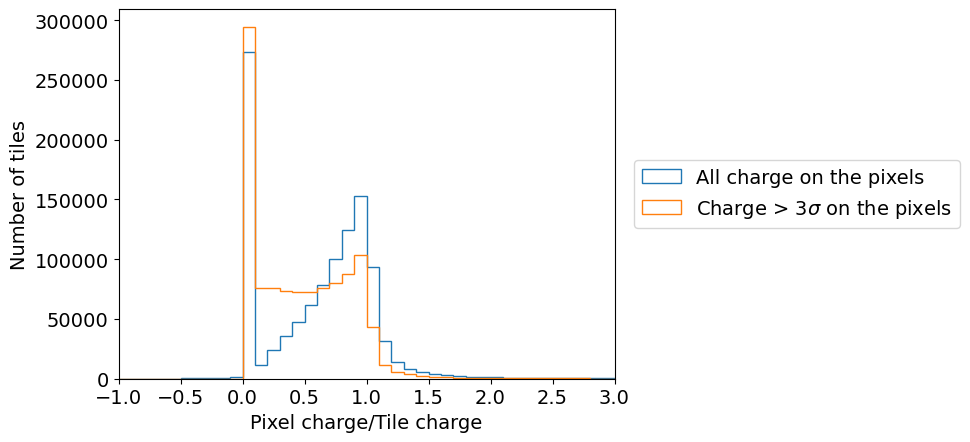

In [20]:
fig, ax = plt.subplots()

rBins = np.linspace(-1, 3, 41)
fonts = 14

ax.hist(dT2['ratio'], bins = rBins, histtype = 'step', label = 'All charge on the pixels')
ax.hist(dT2['ratio_3sd'], bins = rBins, histtype = 'step', label = r'Charge > 3$\sigma$ on the pixels')

ax.set_xlabel('Pixel charge/Tile charge', fontsize = fonts)
ax.set_ylabel('Number of tiles', fontsize = fonts)
ax.set_xlim([-1, 3])
ax.tick_params(axis = "both", labelsize = fonts)
ax.legend(loc = "center left", bbox_to_anchor = (1.02, 0.5), fontsize = fonts)

Require the matched true energy in each tile > 0

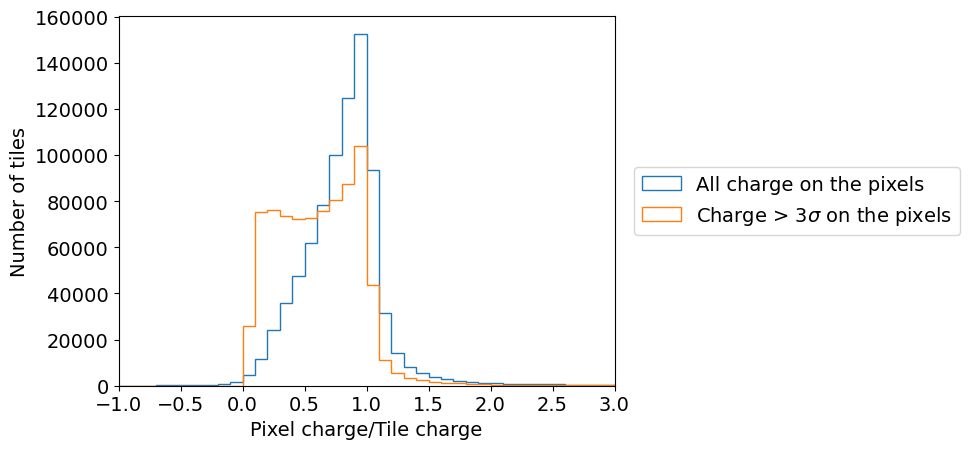

In [21]:
fig, ax = plt.subplots()

rBins = np.linspace(-1, 3, 41)
fonts = 14

ax.hist(dT2.loc[dT2.E>0., 'ratio'], bins = rBins, histtype = 'step', label = 'All charge on the pixels')
ax.hist(dT2.loc[dT2.E>0., 'ratio_3sd'], bins = rBins, histtype = 'step', label = r'Charge > 3$\sigma$ on the pixels')

ax.set_xlabel('Pixel charge/Tile charge', fontsize = fonts)
ax.set_ylabel('Number of tiles', fontsize = fonts)
ax.set_xlim([-1, 3])
ax.tick_params(axis = "both", labelsize = fonts)
ax.legend(loc = "center left", bbox_to_anchor = (1.02, 0.5), fontsize = fonts)

In [22]:
dT2.loc[dT2.E==0., 'charge'].min(), dT2.loc[dT2.E==0., 'charge'].max()

(-759.687686920166, 4689.312581062317)

In [23]:
dT2[(dT2.E_matched==0.)]

,tile_id,event id,trig t,tile x,tile y,charge,z_matched,E_matched,charge_sum,charge_3sd_sum,labels,ratio,ratio_3sd,E,z_avg


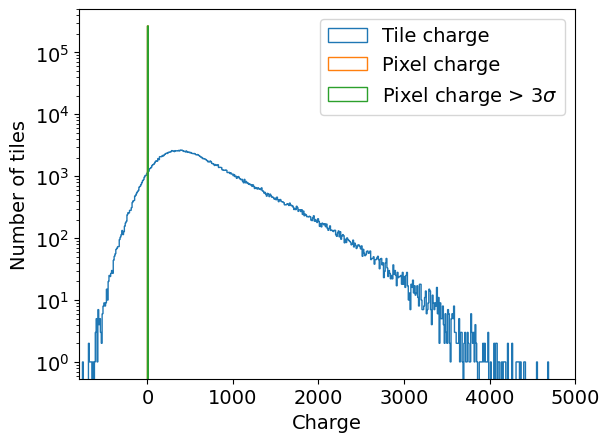

In [24]:
fig, ax = plt.subplots()

cBins = np.linspace(-800, 5000, 581)
fonts = 14

ax.hist(dT2.loc[(dT2.E==0.), 'charge'], bins = cBins, histtype = 'step', label = 'Tile charge')
ax.hist(dT2.loc[(dT2.E==0.), 'charge_sum'], bins = cBins, histtype = 'step', label = 'Pixel charge')
ax.hist(dT2.loc[(dT2.E==0.), 'charge_3sd_sum'], bins = cBins, histtype = 'step', label = r'Pixel charge > 3$\sigma$')

ax.set_xlabel('Charge', fontsize = fonts)
ax.set_ylabel('Number of tiles', fontsize = fonts)
ax.set_xlim([-800, 5000])
ax.tick_params(axis = "both", labelsize = fonts)
ax.set_yscale('log')
ax.legend(fontsize = fonts)

In [25]:
dT2.loc[(dT2.E==0.), 'charge_sum'].min(), dT2.loc[(dT2.E==0.), 'charge_sum'].max(), dT2.loc[(dT2.E==0.), 'charge_3sd_sum'].min(), dT2.loc[(dT2.E==0.), 'charge_3sd_sum'].max()

(0.0, 0.0, 0.0, 0.0)

In [26]:
dT2.loc[(dT2.E==0.), 'E_matched'].min(), dT2.loc[(dT2.E==0.), 'E_matched'].max()

(0.0003019580617547035, 8.785089492797852)

Find the segment energy matched to tiles, but not to pixels

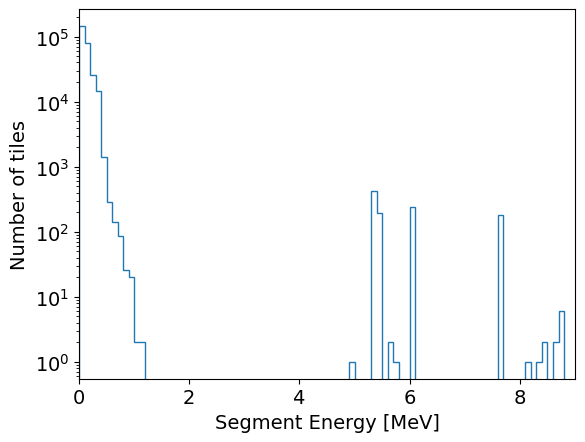

In [27]:
fig, ax = plt.subplots()

cBins = np.linspace(0, 9, 91)
fonts = 14

ax.hist(dT2.loc[(dT2.E==0.), 'E_matched'], bins = cBins, histtype = 'step')

ax.set_xlabel('Segment Energy [MeV]', fontsize = fonts)
ax.set_ylabel('Number of tiles', fontsize = fonts)
ax.set_xlim([0, 9])
ax.tick_params(axis = "both", labelsize = fonts)
ax.set_yscale('log')
# ax.legend(fontsize = fonts)

In [28]:
len(dT2), (dT2['ratio'] < 0).sum(), (dT2['ratio'] == 0).sum(), (dT2['ratio'] > 1).sum()

(1093441, np.int64(6239), np.int64(268795), np.int64(177095))

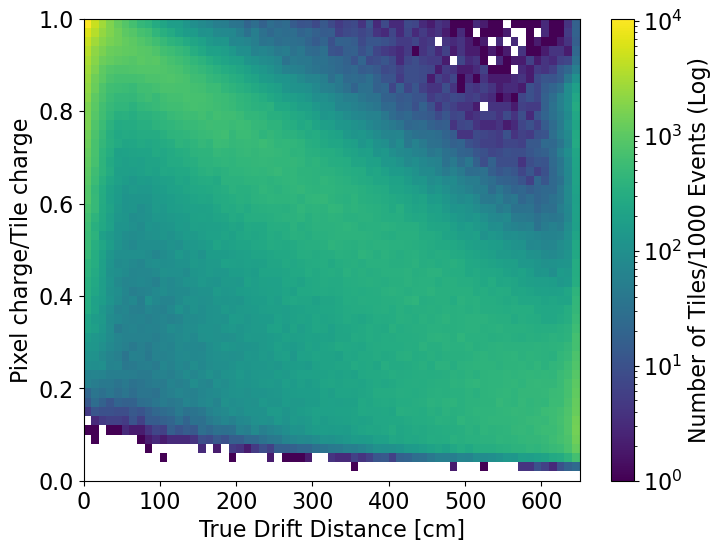

In [29]:
fig, ax = plt.subplots(figsize = (8, 6))

fonts = 16

h = ax.hist2d(325-dT2['z_avg'], dT2['ratio_3sd'], bins = (65, 50), range = [[0, 650], [0, 1]], cmap = 'viridis', norm = colors.LogNorm() )

ax.set_xlabel('True Drift Distance [cm]', fontsize = fonts)
ax.set_ylabel('Pixel charge/Tile charge', fontsize = fonts)
ax.tick_params(axis = "both", labelsize = fonts)
ax.set_xlim([0, 650])
ax.set_ylim([0, 1])

cbar = fig.colorbar(h[3])
cbar.ax.tick_params( labelsize = fonts)     # ticks (numbers)
cbar.set_label("Number of Tiles/1000 Events (Log)", fontsize = fonts) 

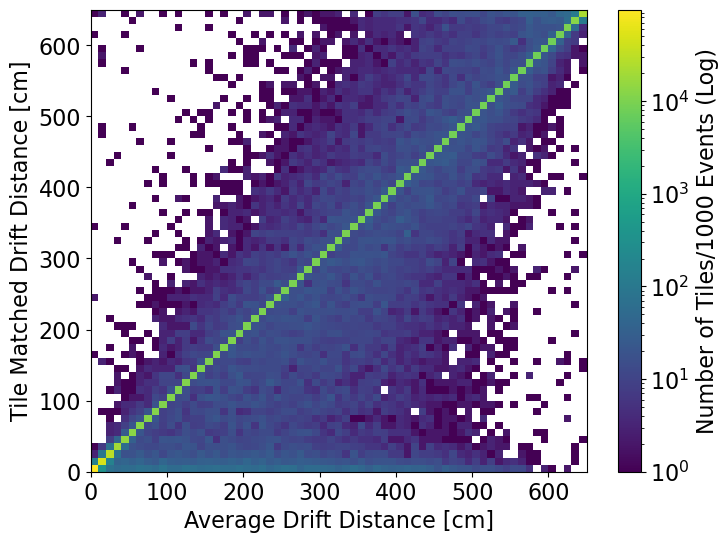

In [30]:
fig, ax = plt.subplots(figsize = (8, 6))

fonts = 16

h = ax.hist2d(325-dT2['z_avg'], 325-dT2['z_matched'], bins = (65, 65), range = [[0, 650], [0, 650]], cmap = 'viridis', norm = colors.LogNorm() )

ax.set_xlabel('Average Drift Distance [cm]', fontsize = fonts)
ax.set_ylabel('Tile Matched Drift Distance [cm]', fontsize = fonts)
ax.tick_params(axis = "both", labelsize = fonts)
ax.set_xlim([0, 650])
ax.set_ylim([0, 650])

cbar = fig.colorbar(h[3])
cbar.ax.tick_params( labelsize = fonts)     # ticks (numbers)
cbar.set_label("Number of Tiles/1000 Events (Log)", fontsize = fonts) 

In [31]:
dT2[(dT2.z_matched>315) & (dT2.z_avg<315)]

,tile_id,event id,trig t,tile x,tile y,charge,z_matched,E_matched,charge_sum,charge_3sd_sum,labels,ratio,ratio_3sd,E,z_avg
341,341,0,-2015.445801,-945.0,-575.0,6539.382748,318.954224,0.359150,7680.913101,7044.445190,"[5747, 5748, 8499, -9999, -9999, -9999, -9999,...",1.174562,1.077234,0.469149,203.433197
511,511,0,3600.554199,-905.0,-495.0,3663.937103,324.571381,0.268288,3116.577774,3545.626465,"[2622, 2621, 9482, -9999, -9999, -9999, -9999,...",0.850609,0.967709,0.416285,102.560852
514,514,0,3600.554199,-905.0,-485.0,1215.553621,324.571381,0.268288,1422.633201,1026.153595,"[2622, 9482, -9999, -9999, -9999, -9999, -9999...",1.170358,0.844186,0.413108,100.853249
685,685,0,1475.554199,-865.0,-505.0,2010.686431,315.514618,0.139565,2137.736504,1794.261230,"[6982, 6981, 6980, -9999, -9999, -9999, -9999,...",1.063187,0.892363,0.211467,314.263641
827,827,0,2637.554199,-835.0,-305.0,37268.191492,315.168701,0.495870,37328.155465,37125.355469,"[1981, 1982, 1978, 1979, 1980, -9999, -9999, -...",1.001609,0.996167,1.654591,314.750916
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1090972,1090972,997,-2517.991699,-835.0,-425.0,7452.335316,316.511597,0.381160,7831.031565,7285.541245,"[8817367, 8816776, -9999, -9999, -9999, -9999,...",1.050816,0.977619,0.530194,170.469925
1091232,1091232,997,891.008301,-755.0,-475.0,1763.844728,318.613708,0.095116,1087.070668,1229.050751,"[8817760, 8817683, -9999, -9999, -9999, -9999,...",0.616307,0.696802,0.255076,204.448654
1091576,1091576,998,23.613525,-965.0,-355.0,1278.645200,319.541626,0.090072,1132.532691,1116.424622,"[8824087, 8824086, 8825960, -9999, -9999, -999...",0.885729,0.873131,0.503561,61.300583
1092878,1092878,999,-488.833252,-895.0,-485.0,1312.991461,322.773010,0.059849,1893.894093,1161.858719,"[8832410, 8832409, 8833882, 8832406, 8832405, ...",1.442427,0.884894,0.272662,122.143700


In [32]:
z_mask = (dT2.z_matched>315) & (dT2.z_avg<315)
dT2[z_mask].E.min(), dT2[z_mask].E.max(), dT2[z_mask].E_matched.min(), dT2[z_mask].E_matched.max()

(0.015053810551762581,
 8.518387794494629,
 0.0010908459080383182,
 5.4895405769348145)

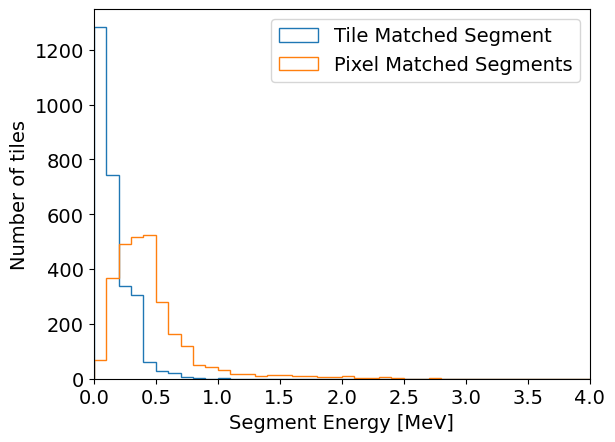

In [33]:
fig, ax = plt.subplots()

eBins = np.linspace(0, 9, 91)
fonts = 14

ax.hist(dT2.loc[z_mask, 'E_matched'], bins = eBins, histtype = 'step', label = 'Tile Matched Segment')
ax.hist(dT2.loc[z_mask, 'E'], bins = eBins, histtype = 'step', label = 'Pixel Matched Segments')

ax.set_xlabel('Segment Energy [MeV]', fontsize = fonts)
ax.set_ylabel('Number of tiles', fontsize = fonts)
ax.set_xlim([0, 4])
ax.tick_params(axis = "both", labelsize = fonts)
# ax.set_yscale('log')
ax.legend(fontsize = fonts)

In [34]:
dT2[dT2.ratio_3sd==0].charge_3sd_sum

0          0.0
1          0.0
2          0.0
3          0.0
4          0.0
          ... 
1093421    0.0
1093422    0.0
1093429    0.0
1093430    0.0
1093436    0.0
Name: charge_3sd_sum, Length: 268795, dtype: float64

In [35]:
dT2[dT2.ratio_3sd<0]

,tile_id,event id,trig t,tile x,tile y,charge,z_matched,E_matched,charge_sum,charge_3sd_sum,labels,ratio,ratio_3sd,E,z_avg
227,227,0,3718.054199,-975.0,-535.0,-93.892279,314.556946,0.044036,165.250308,235.551743,"[8968, -9999, -9999, -9999, -9999, -9999, -999...",-1.759999,-2.508745,0.044036,314.556946
316,316,0,-1273.445801,-955.0,-405.0,-86.448915,324.135925,0.030782,429.567372,186.463852,"[5660, -9999, -9999, -9999, -9999, -9999, -999...",-4.969031,-2.156925,0.030782,324.135925
578,578,0,28.054199,-885.0,-585.0,-247.378418,323.164093,0.046342,470.462458,434.183319,"[3620, -9999, -9999, -9999, -9999, -9999, -999...",-1.901793,-1.755138,0.046342,323.164093
715,715,0,-2511.445801,-855.0,-575.0,-40.155633,320.701233,0.036430,545.430239,210.275879,"[7126, -9999, -9999, -9999, -9999, -9999, -999...",-13.582907,-5.236523,0.036430,320.701233
1491,1491,1,256.231934,-955.0,-405.0,-13.523211,-323.158447,0.056598,4803.523310,3361.616409,"[16559, 16560, 16570, -9999, -9999, -9999, -99...",-355.205837,-248.581238,0.605664,-324.129639
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1092323,1092323,998,2156.113525,-745.0,-535.0,-105.308839,300.427734,0.122583,1814.624712,1263.809418,"[8821649, -9999, -9999, -9999, -9999, -9999, -...",-17.231457,-12.000981,0.122583,300.427734
1092636,1092636,999,-2715.333252,-965.0,-545.0,-55.049249,201.883774,0.291875,219.894601,169.246490,"[8834508, 8834509, 8834054, -9999, -9999, -999...",-3.994507,-3.074456,0.432509,127.356781
1092880,1092880,999,-3151.833252,-895.0,-455.0,-62.987988,240.147232,0.043860,513.180437,180.081757,"[8834519, -9999, -9999, -9999, -9999, -9999, -...",-8.147275,-2.858986,0.043860,240.147217
1092912,1092912,999,-497.333252,-885.0,-485.0,-478.217826,324.579956,0.028603,326.565297,254.211411,"[8832411, -9999, -9999, -9999, -9999, -9999, -...",-0.682880,-0.531581,0.028603,324.579926


In [36]:
dT2[dT2.ratio_3sd>1]

,tile_id,event id,trig t,tile x,tile y,charge,z_matched,E_matched,charge_sum,charge_3sd_sum,labels,ratio,ratio_3sd,E,z_avg
5,5,0,-3109.945801,-1055.0,-575.0,1184.644737,306.181946,0.109424,1102.951938,1332.441254,"[5816, -9999, -9999, -9999, -9999, -9999, -999...",0.931040,1.124760,0.109424,306.181946
21,21,0,1486.054199,-1045.0,-435.0,41944.679278,313.405823,0.539152,42136.552195,42210.030319,"[4845, 4844, 4847, 4848, 4846, -9999, -9999, -...",1.004574,1.006326,1.595379,313.630402
28,28,0,3456.054199,-1045.0,-385.0,908.478144,318.292908,0.083518,914.908132,984.408707,"[4834, 4833, -9999, -9999, -9999, -9999, -9999...",1.007078,1.083580,0.086695,318.293488
56,56,0,-4032.445801,-1035.0,-385.0,2906.897236,324.810913,0.200018,3083.094446,3139.303711,"[9510, -9999, -9999, -9999, -9999, -9999, -999...",1.060613,1.079950,0.200018,324.810883
64,64,0,-2366.445801,-1025.0,-595.0,1284.803135,212.699860,0.283542,1295.347182,1603.797775,"[8546, -9999, -9999, -9999, -9999, -9999, -999...",1.008207,1.248283,0.283542,212.699860
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1093424,1093424,999,-262.333252,-745.0,-405.0,9028.887832,318.918030,0.364325,8948.069588,9083.784180,"[8834001, 8834002, -9999, -9999, -9999, -9999,...",0.991049,1.006080,0.462395,318.922180
1093432,1093432,999,-3247.833252,-735.0,-485.0,1655.869660,323.696960,0.134956,1673.739249,1767.375732,"[8828763, -9999, -9999, -9999, -9999, -9999, -...",1.010792,1.067340,0.134956,323.696960
1093433,1093433,999,-3107.333252,-735.0,-485.0,1283.297315,301.072601,0.098826,1366.036788,1394.389801,"[8828755, 8828754, 8828756, -9999, -9999, -999...",1.064474,1.086568,0.112241,301.072815
1093434,1093434,999,-3065.333252,-735.0,-485.0,751.876325,292.873413,0.243623,4810.885618,3737.891724,"[8828761, -9999, -9999, -9999, -9999, -9999, -...",6.398507,4.971418,0.243623,292.873413


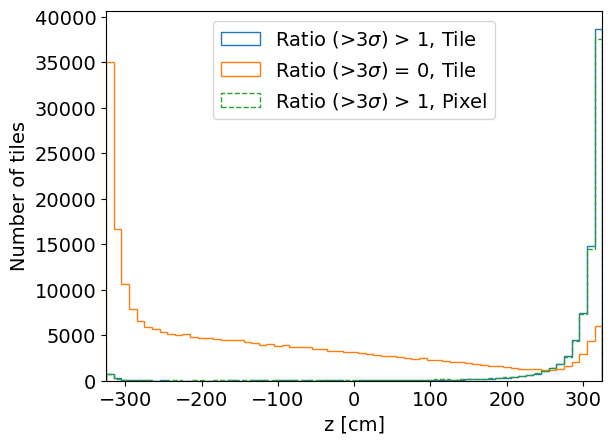

In [37]:
ratio_3sd_gt_1 = dT2.ratio_3sd>1
ratio_3sd_eq_0 = dT2.ratio_3sd == 0

fig, ax = plt.subplots()

zBins = np.linspace(-325, 325, 66)
fonts = 14

ax.hist(dT2.loc[ratio_3sd_gt_1, 'z_matched'], bins = zBins, histtype = 'step', label = r'Ratio (>3$\sigma$) > 1, Tile')
ax.hist(dT2.loc[ratio_3sd_eq_0, 'z_matched'], bins = zBins, histtype = 'step', label = r'Ratio (>3$\sigma$) = 0, Tile')
ax.hist(dT2.loc[ratio_3sd_gt_1, 'z_avg'], bins = zBins, histtype = 'step', linestyle = '--', label = r'Ratio (>3$\sigma$) > 1, Pixel')

ax.set_xlabel('z [cm]', fontsize = fonts)
ax.set_ylabel('Number of tiles', fontsize = fonts)
ax.set_xlim([-325, 325])
ax.tick_params(axis = "both", labelsize = fonts)
ax.legend(loc = 'upper center', fontsize = fonts)

In [38]:
dT2[ratio_3sd_eq_0 & (dT2.E > 0)]

,tile_id,event id,trig t,tile x,tile y,charge,z_matched,E_matched,charge_sum,charge_3sd_sum,labels,ratio,ratio_3sd,E,z_avg


Matched true energy

In [39]:
dT2['E_matched'].max(), dT2['E'].max()

(8.785089492797852, 10.488239288330078)

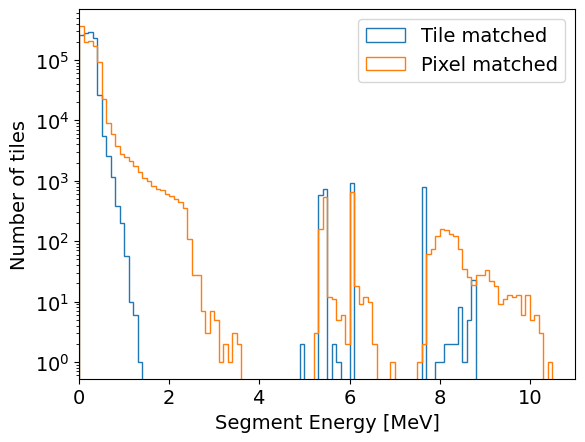

In [40]:
fig, ax = plt.subplots()

eBins = np.linspace(0, 11, 111)
fonts = 14

ax.hist(dT2['E_matched'], bins = eBins, histtype = 'step', label = 'Tile matched')
ax.hist(dT2['E'], bins = eBins, histtype = 'step', label = 'Pixel matched')

ax.set_xlabel('Segment Energy [MeV]', fontsize = fonts)
ax.set_ylabel('Number of tiles', fontsize = fonts)
ax.set_xlim([0, 11])
ax.tick_params(axis = "both", labelsize = fonts)
ax.set_yscale('log')
ax.legend(fontsize = fonts)

2D histograms for each energy slice

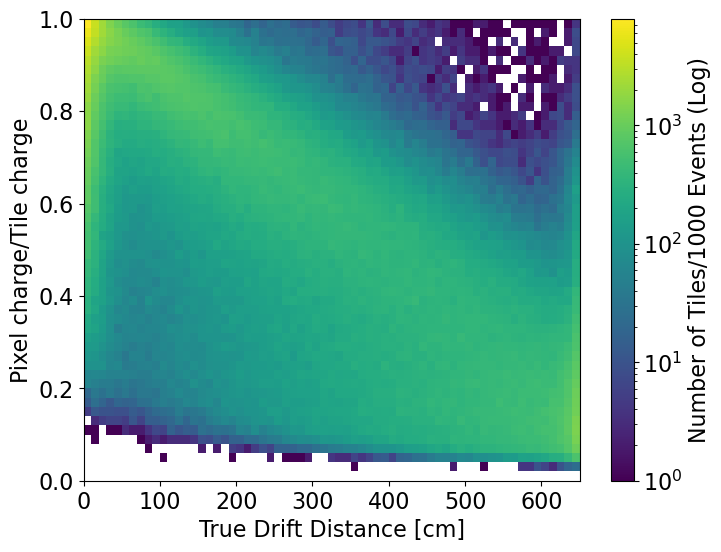

In [41]:
e_mask = dT2['E']<1
fig, ax = plt.subplots(figsize = (8, 6))

fonts = 16

h = ax.hist2d(325-dT2.loc[e_mask, 'z_avg'], dT2.loc[e_mask, 'ratio_3sd'], bins = (65, 50), range = [[0, 650], [0, 1]], cmap = 'viridis', norm = colors.LogNorm() )

ax.set_xlabel('True Drift Distance [cm]', fontsize = fonts)
ax.set_ylabel('Pixel charge/Tile charge', fontsize = fonts)
ax.tick_params(axis = "both", labelsize = fonts)
ax.set_xlim([0, 650])
ax.set_ylim([0, 1])

cbar = fig.colorbar(h[3])
cbar.ax.tick_params( labelsize = fonts)     # ticks (numbers)
cbar.set_label("Number of Tiles/1000 Events (Log)", fontsize = fonts) 

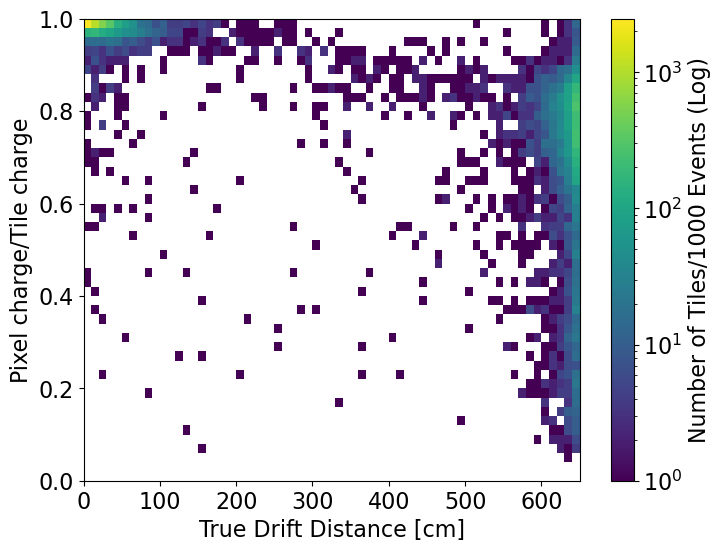

In [42]:
e_mask = (dT2['E']>=1) & (dT2['E']<4)
fig, ax = plt.subplots(figsize = (8, 6))

fonts = 16

h = ax.hist2d(325-dT2.loc[e_mask, 'z_avg'], dT2.loc[e_mask, 'ratio_3sd'], bins = (65, 50), range = [[0, 650], [0, 1]], cmap = 'viridis', norm = colors.LogNorm() )

ax.set_xlabel('True Drift Distance [cm]', fontsize = fonts)
ax.set_ylabel('Pixel charge/Tile charge', fontsize = fonts)
ax.tick_params(axis = "both", labelsize = fonts)
ax.set_xlim([0, 650])
ax.set_ylim([0, 1])

cbar = fig.colorbar(h[3])
cbar.ax.tick_params( labelsize = fonts)     # ticks (numbers)
cbar.set_label("Number of Tiles/1000 Events (Log)", fontsize = fonts) 

In [43]:
def sumCharge(series_of_lists, thr):
    # series_of_lists: pandas Series where each entry is list/np.array
    return float(np.sum([np.sum(a[a > thr]) for a in map(np.asarray, series_of_lists)]))
# def sumCharge()

In [45]:
threshold = 3*noise
nLabels = 20

# --- Prep (keep only needed cols to reduce memory) ---
dP3 = dP.reset_index(drop = True).copy()
dT3 = dT.reset_index(drop = True).copy()

dP3["pixel_id"] = dP3.index
dT3["tile_id"]  = dT3.index

# If you have event id, keep it; otherwise remove those lines below
need_cols_p = ["pixel_id", "event id", "trig t", "pixel x", "pixel y", "charge", "waveform", "label"]
need_cols_t = ["tile_id",  "event id", "trig t", "tile x",  "tile y", "charge", "z_matched", "E_matched"]
dP3 = dP3[need_cols_p]
dT3 = dT3[need_cols_t]

# Sort dP for searchsorted by time (within each event id works best; see approach 2 if many events)
# If you only have ONE event, just sort by "hit t".
dP3 = dP3.sort_values(["event id", "trig t"]).reset_index(drop = True)

# We'll process per event id to keep time search correct and candidate sizes small
matches_parts = []
sum_parts = []
label_parts = []

for ev, t_ev in dT3.groupby("event id", sort = False):
    p_ev = dP3[dP3["event id"] == ev]
    if p_ev.empty:
        continue

    tP = p_ev["trig t"].to_numpy()
    # For each tile, get [t, t+10]
    tT = t_ev["trig t"].to_numpy()

    left  = np.searchsorted(tP, tT, side = "left")
    right = np.searchsorted(tP, tT + 10, side = "right")

    # Iterate tiles in this event; slices are only the time-window subset
    # (If this is still slow, we can optimize further, but it won’t blow memory.)
    for (tile_id, trig_t, tx, ty), l, r in zip(
        t_ev[["tile_id", "trig t", "tile x", "tile y"]].itertuples(index = False, name = None),
        left,
        right,
    ):
        if l >= r:
            continue

        sub = p_ev.iloc[l:r]

        m = (
            (sub["pixel x"] > tx - 5) & (sub["pixel x"] < tx + 5) &
            (sub["pixel y"] > ty - 5) & (sub["pixel y"] < ty + 5)
        )
        if not m.any():
            continue

        subm = sub.loc[m, ["pixel_id", "trig t", "pixel x", "pixel y", "charge", "waveform", "label"]].copy()
        subm["tile_id"] = tile_id

        matches_parts.append(subm[["tile_id", "pixel_id", "trig t", "pixel x", "pixel y"]])
        sum_parts.append((tile_id, float(subm["charge"].sum()), sumCharge(subm["waveform"], threshold)))

        # Collect labels for this tile from all matched rows in this sub-window.
        # Each subm["label"] cell is a 3-element list; concatenate them.
        # (If any label cells can be NaN/None, filter them out.)
        labels_concat = []
        for ilabel in subm["label"]:
            if ilabel is None or (isinstance(ilabel, float) and np.isnan(ilabel)):
                continue
            labels_concat.extend(ilabel)
        label_parts.append((tile_id, labels_concat))


# Build outputs
matches = pd.concat(matches_parts, ignore_index = True) if matches_parts else pd.DataFrame(
    columns=["tile_id", "pixel_id", "trig t", "pixel x", "pixel y"]
)

charge_sum = pd.DataFrame(sum_parts, columns = ["tile_id", "charge_sum", "charge_3sd_sum"])  # .groupby("tile_id", as_index = False)["charge_sum"].sum()

# --- NEW: build per-tile unique label list (len=10, pad with -9999) ---
if label_parts:
    labels = pd.DataFrame(label_parts, columns = ["tile_id", "labels_concat"])
    labels = labels.groupby("tile_id", sort = False)["labels_concat"].sum().reset_index()

    def uniq_drop_pad(labels, pad = -9999, n = nLabels):
        out = []
        seen = set()
        for x in labels:
            if x == pad:
                continue
            if x in seen:
                continue
            seen.add(x)
            out.append(x)
            if len(out) == n:
                break
        if len(out) < n:
            out.extend([pad] * (n - len(out)))
        return out

    labels["labels"] = labels["labels_concat"].map(uniq_drop_pad)
    labels = labels[["tile_id", "labels"]]
else:
    labels = pd.DataFrame(columns = ["tile_id", "labels"])

# Add the sum onto every matching row (and/or onto dC)
matches = matches.merge(charge_sum, on = "tile_id", how = "left")
dT3 = dT3.merge(charge_sum, on = "tile_id", how = "left")
dT3["charge_sum"] = dT3["charge_sum"].fillna(0)
dT3["charge_3sd_sum"] = dT3["charge_3sd_sum"].fillna(0)
dT3 = dT3.merge(labels, on = "tile_id", how = "left")
dT3["labels"] = dT3["labels"].apply(lambda x: x if isinstance(x, list) else [-9999]*nLabels)

# If you want to write back:
dT["charge_sum"] = dT3.sort_values("tile_id")["charge_sum"].to_numpy()

In [46]:
dT3['ratio'] = dT3['charge_sum']/dT3['charge']
dT3['ratio_3sd'] = dT3['charge_3sd_sum']/dT3['charge']
dT3

,tile_id,event id,trig t,tile x,tile y,charge,z_matched,E_matched,charge_sum,charge_3sd_sum,labels,ratio,ratio_3sd
0,0,0,5804.554199,-1065.0,-575.0,1386.506609,-308.297485,0.100299,15.948111,0.000000,"[8158, 8157, -9999, -9999, -9999, -9999, -9999...",0.011502,0.000000
1,1,0,6371.054199,-1065.0,-545.0,304.031366,-323.626770,0.071440,0.000000,0.000000,"[-9999, -9999, -9999, -9999, -9999, -9999, -99...",0.000000,0.000000
2,2,0,6377.554199,-1065.0,-535.0,966.326665,-324.471558,0.124203,405.021456,0.000000,"[8100, 8099, -9999, -9999, -9999, -9999, -9999...",0.419135,0.000000
3,3,0,-3552.445801,-1055.0,-575.0,480.919051,323.147705,0.034409,0.000000,0.000000,"[-9999, -9999, -9999, -9999, -9999, -9999, -99...",0.000000,0.000000
4,4,0,-3161.945801,-1055.0,-575.0,126.962569,314.573944,0.028863,0.000000,0.000000,"[-9999, -9999, -9999, -9999, -9999, -9999, -99...",0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1093436,1093436,999,-3072.333252,-735.0,-475.0,344.125580,295.296478,0.043029,473.166698,0.000000,"[8828759, 8828758, -9999, -9999, -9999, -9999,...",1.374983,0.000000
1093437,1093437,999,2227.666748,-735.0,-365.0,1105.921688,318.097504,0.075019,628.371725,794.411911,"[8830264, 8830263, -9999, -9999, -9999, -9999,...",0.568188,0.718326
1093438,1093438,999,2380.666748,-735.0,-355.0,34607.093809,-314.596924,0.564141,33867.234197,28422.969498,"[8833149, 8833150, 8833152, 8833151, 8833153, ...",0.978621,0.821305
1093439,1093439,999,2405.666748,-735.0,-355.0,424.614502,-318.462036,0.035142,4103.829427,657.842041,"[8833145, 8833148, 8833147, 8833146, -9999, -9...",9.664836,1.549269


In [47]:
(dT3['labels'].str[-1]!=-9999).sum()

np.int64(0)

Similar to the other matching algorithm -- match the edep-sim segments and sum over the dE of the segments matched to a tile.

Calculate the weighted average drift distance by (dE1&times;x1+dE2&times;x2+dE3&times;x3+....)/(dE1+dE2+dE3+....).
Note that `x` in dS is the drift distance, and is renamed as `z` in dT/dT2/etc. 

In [48]:
# Weighted average of x over the matched dS rows:
#   x_weighted = sum(dE * x) / sum(dE)
# computed per (event id, tile_id) in dT2.

# 1) explode labels to long form
t3_long = (
    dT3[["event id", "tile_id", "labels"]]
    .explode("labels", ignore_index = True)
    .rename(columns = {"labels": "segment_id"})
)

# 2) drop padding
t3_long = t3_long[t3_long["segment_id"].ne(-9999)]

# 3) join to dS on event + segment
m = t3_long.merge(
    dS[["event_id", "segment_id", "dE", "x"]],   # <-- use your x column name here
    left_on = ["event id", "segment_id"],
    right_on = ["event_id", "segment_id"],
    how = "inner",
)

# numerator and denominator
m["dE_x"] = m["dE"] * m["x"]

# sum over dE and dE*x
agg = (
    m.groupby(["event id", "tile_id"], sort = False, as_index = False)
     .agg(E = ("dE", "sum"), dE_x_sum = ("dE_x", "sum"))
)

agg["z_avg"] = agg["dE_x_sum"] / agg["E"]

# attach back to dT2
dT3 = dT3.merge(agg[["event id", "tile_id", "E", "z_avg"]],
                on = ["event id", "tile_id"], how = "left")

# handle no-match (or zero total energy) rows
dT3["E"] = dT3["E"].fillna(0.0)
dT3["z_avg"] = dT3["z_avg"].where(dT3["E"] > 0, np.nan)

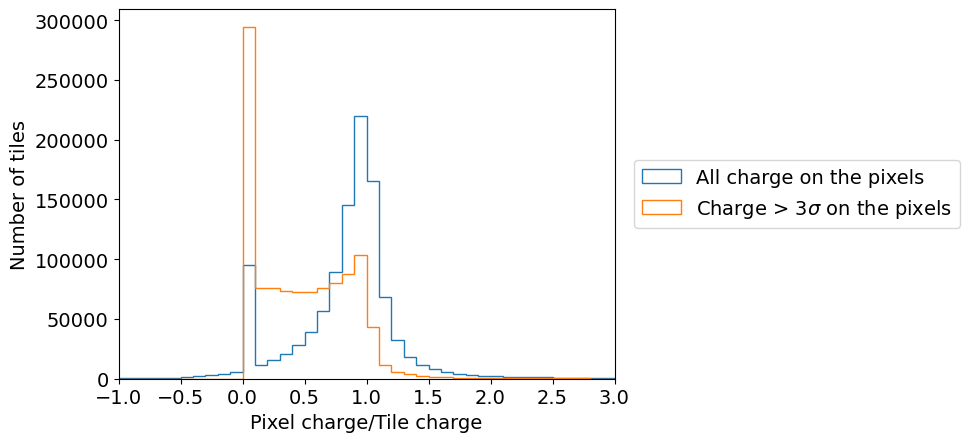

In [50]:
fig, ax = plt.subplots()

rBins = np.linspace(-1, 3, 41)
fonts = 14

ax.hist(dT3['ratio'], bins = rBins, histtype = 'step', label = 'All charge on the pixels')
ax.hist(dT3['ratio_3sd'], bins = rBins, histtype = 'step', label = r'Charge > 3$\sigma$ on the pixels')
# ax.hist(dT2['ratio_3sd'], bins = rBins, histtype = 'step', label = r'Charge > 3$\sigma$ on the pixels (algo 1)')

ax.set_xlabel('Pixel charge/Tile charge', fontsize = fonts)
ax.set_ylabel('Number of tiles', fontsize = fonts)
ax.set_xlim([-1, 3])
ax.tick_params(axis = "both", labelsize = fonts)
ax.legend(loc = "center left", bbox_to_anchor = (1.02, 0.5), fontsize = fonts)

In [51]:
dT3['E'].max()

10.735628128051758

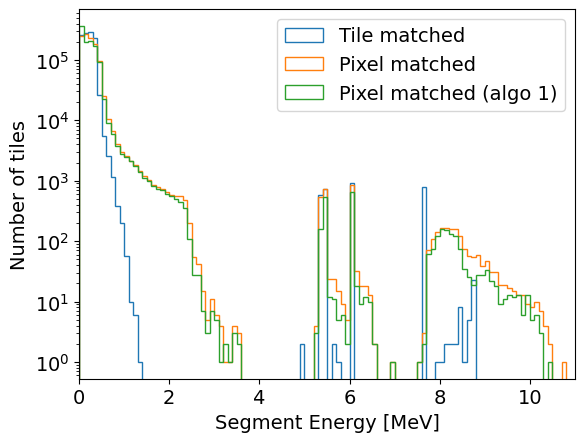

In [52]:
fig, ax = plt.subplots()

eBins = np.linspace(0, 11, 111)
fonts = 14

ax.hist(dT3['E_matched'], bins = eBins, histtype = 'step', label = 'Tile matched')
ax.hist(dT3['E'], bins = eBins, histtype = 'step', label = 'Pixel matched')
ax.hist(dT2['E'], bins = eBins, histtype = 'step', label = 'Pixel matched (algo 1)')

ax.set_xlabel('Segment Energy [MeV]', fontsize = fonts)
ax.set_ylabel('Number of tiles', fontsize = fonts)
ax.set_xlim([0, 11])
ax.tick_params(axis = "both", labelsize = fonts)
ax.set_yscale('log')
ax.legend(fontsize = fonts)

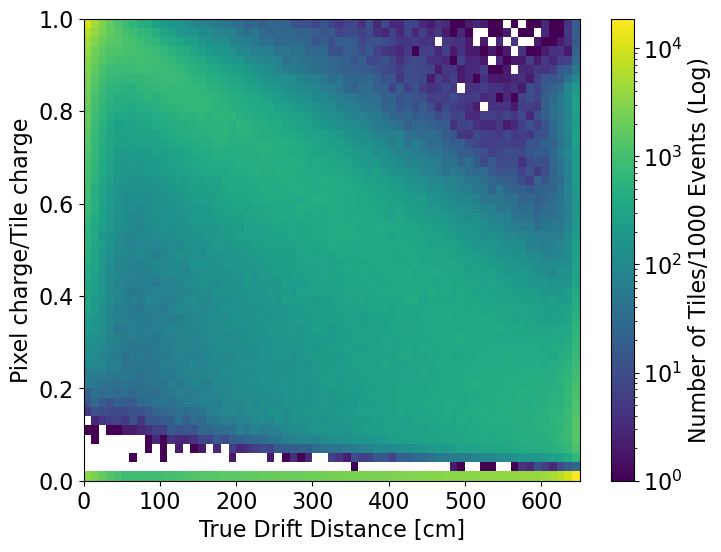

In [53]:
fig, ax = plt.subplots(figsize = (8, 6))

fonts = 16

h = ax.hist2d(325-dT3['z_avg'], dT3['ratio_3sd'], bins = (65, 50), range = [[0, 650], [0, 1]], cmap = 'viridis', norm = colors.LogNorm() )

ax.set_xlabel('True Drift Distance [cm]', fontsize = fonts)
ax.set_ylabel('Pixel charge/Tile charge', fontsize = fonts)
ax.tick_params(axis = "both", labelsize = fonts)
ax.set_xlim([0, 650])
ax.set_ylim([0, 1])

cbar = fig.colorbar(h[3])
cbar.ax.tick_params( labelsize = fonts)     # ticks (numbers)
cbar.set_label("Number of Tiles/1000 Events (Log)", fontsize = fonts) 

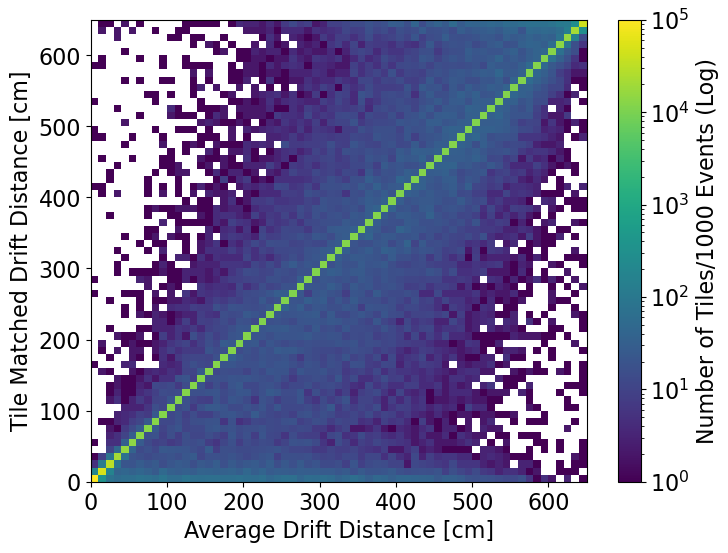

In [54]:
fig, ax = plt.subplots(figsize = (8, 6))

fonts = 16

h = ax.hist2d(325-dT3['z_avg'], 325-dT3['z_matched'], bins = (65, 65), range = [[0, 650], [0, 650]], cmap = 'viridis', norm = colors.LogNorm() )

ax.set_xlabel('Average Drift Distance [cm]', fontsize = fonts)
ax.set_ylabel('Tile Matched Drift Distance [cm]', fontsize = fonts)
ax.tick_params(axis = "both", labelsize = fonts)
ax.set_xlim([0, 650])
ax.set_ylim([0, 650])

cbar = fig.colorbar(h[3])
cbar.ax.tick_params( labelsize = fonts)     # ticks (numbers)
cbar.set_label("Number of Tiles/1000 Events (Log)", fontsize = fonts) 

Conclusion: Will use dT3/Algo 2 for the future studies, as it is the most comprehensive matching algorithm.